In [65]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## 1 Revenue by Customer Segment Over Time 

In [66]:
customers = pd.read_csv("dataset/olist_customers_dataset.csv")
print(customers.dtypes)

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object


In [67]:
orders = pd.read_csv("dataset/olist_orders_dataset.csv")
print(orders.dtypes)

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [68]:
payments = pd.read_csv("dataset/olist_order_payments_dataset.csv")
print(payments.dtypes)

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object


In [69]:
df = orders.merge(customers,on="customer_id")
df = df.merge(payments,on="order_id")

In [70]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [71]:
print(df.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
payment_sequential                        int64
payment_type                             object
payment_installments                      int64
payment_value                           float64
dtype: object


In [72]:
rfm = df.groupby("customer_unique_id").agg(
    last_purchase = ("order_purchase_timestamp","max"),
    frequency = ("order_id","count"),
    monetary = ("payment_value","sum")
).reset_index()

In [73]:
print(rfm)

                     customer_unique_id       last_purchase  frequency  \
0      0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:27          1   
1      0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:27          1   
2      0000f46a3911fa3c0805444483337064 2017-03-10 21:05:03          1   
3      0000f6ccb0745a6a4b88665a16c9f078 2017-10-12 20:29:41          1   
4      0004aac84e0df4da2b147fca70cf8255 2017-11-14 19:45:42          1   
...                                 ...                 ...        ...   
96090  fffcf5a5ff07b0908bd4e2dbc735a684 2017-06-08 21:00:36          1   
96091  fffea47cd6d3cc0a88bd621562a9d061 2017-12-10 20:07:56          1   
96092  ffff371b4d645b6ecea244b27531430a 2017-02-07 15:49:16          1   
96093  ffff5962728ec6157033ef9805bacc48 2018-05-02 15:17:41          1   
96094  ffffd2657e2aad2907e67c3e9daecbeb 2017-05-02 20:18:45          1   

       monetary  
0        141.90  
1         27.19  
2         86.22  
3         43.62  
4        196.89  
...

In [74]:
print(rfm.index)

RangeIndex(start=0, stop=96095, step=1)


In [75]:
rfm["last_purchase"].dtype

dtype('<M8[ns]')

In [76]:
today = df["order_purchase_timestamp"].max()
print("today : ",today)

rfm["recency"] = (today  - rfm["last_purchase"]).dt.days
print(rfm["recency"])


today :  2018-10-17 17:30:18
0        160
1        163
2        585
3        369
4        336
        ... 
96090    495
96091    310
96092    617
96093    168
96094    532
Name: recency, Length: 96095, dtype: int64


In [77]:
# Recency (lower is better -> reverse labels.. )
rfm["R_score"] = pd.qcut(rfm["recency"],5,labels=[5,4,3,2,1])
print(rfm["R_score"])

0        4
1        4
2        1
3        2
4        2
        ..
96090    1
96091    3
96092    1
96093    4
96094    1
Name: R_score, Length: 96095, dtype: category
Categories (5, int64): [5 < 4 < 3 < 2 < 1]


In [78]:
result = pd.qcut(rfm["recency"],5)
print(result)

0        (142.0, 227.0]
1        (142.0, 227.0]
2        (433.0, 772.0]
3        (317.0, 433.0]
4        (317.0, 433.0]
              ...      
96090    (433.0, 772.0]
96091    (227.0, 317.0]
96092    (433.0, 772.0]
96093    (142.0, 227.0]
96094    (433.0, 772.0]
Name: recency, Length: 96095, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 142.0] < (142.0, 227.0] < (227.0, 317.0] < (317.0, 433.0] < (433.0, 772.0]]


In [79]:
# frequency (use rank to avoid error )
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)
print(rfm["F_score"])

0        1
1        1
2        1
3        1
4        1
        ..
96090    5
96091    5
96092    5
96093    5
96094    5
Name: F_score, Length: 96095, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


In [80]:
# Monetary 
rfm["M_score"] = pd.qcut(rfm["monetary"],5,labels=[1,2,3,4,5])
print(rfm["M_score"])

0        4
1        1
2        2
3        1
4        4
        ..
96090    5
96091    2
96092    3
96093    4
96094    2
Name: M_score, Length: 96095, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


In [81]:
rfm["RFM_score"] = (rfm["R_score"].astype(str) + rfm["M_score"].astype(str) + rfm["M_score"].astype(str))

In [82]:
print(rfm["RFM_score"])

0        444
1        411
2        122
3        211
4        244
        ... 
96090    155
96091    322
96092    133
96093    444
96094    122
Name: RFM_score, Length: 96095, dtype: object


In [83]:
# convert scores to int 
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)


def segment(row):

    # 🟣 Champions (best customers)
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champion"

    # 🔵 Loyal Customers (frequent + decent spending, recent enough)
    elif row["F_score"] >= 4 and row["M_score"] >= 3:
        return "Loyal"

    # 🟡 Potential / New Customers (recent but not strong yet)
    elif row["R_score"] >= 4:
        return "Potential"

    # 🔴 Others (inactive or low value)
    else:
        return "Others"

rfm["segment"] = rfm.apply(segment, axis=1)    

In [84]:
df["year"] = df["order_purchase_timestamp"].dt.year

df = df.merge(rfm[["customer_unique_id", "segment"]], on="customer_unique_id")

segment_year = df.groupby(["year", "segment"])["payment_value"].sum().reset_index()

<Axes: xlabel='year', ylabel='payment_value'>

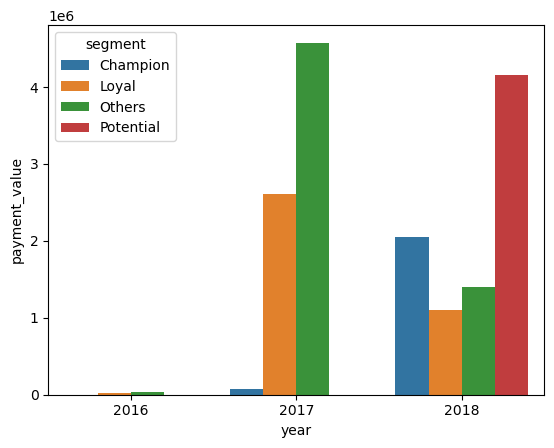

In [85]:
sns.barplot(
    data=segment_year,
    x="year",
    y="payment_value",
    hue="segment"
)